# Summary

This notebook is an adaptation of `FuelCellPINN_V1,2_RAR.py` from a python file to a notebook file for section testing and understanding.

In [1]:
#Fuel Cell PINN Model V1.2 - DeepXDE with PyTorch
#Bailey Steger - 9/16/2026
#Residual-based adaptive refinement
##########################################


import os
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

#GPU check
print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("GPU available:", torch.cuda.is_available())

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


PyTorch version: 2.14.0+cu126
CUDA version: 12.6
GPU available: True


In [2]:
#1) DEFINE MODEL INPUTS
rho = 998 #kg/m^3 #CONSTANT FOR NOW
mu = 0.001002 #N*s/m^2 #CONSTANT FOR NOW
u0 = 0.1 #m/s
L=0.1 #m, tube length
R=0.0075 #m, tube radius
L_R = L/R
Re = rho*u0*2*R/mu

#2) FORMAT GEOMETRY

flowbox = dde.geometry.Rectangle([0,0],[L_R,1])
# timedomain = dde.geometry.TimeDomain(0, 10)

# geom = dde.geometry.GeometryXTime(flowbox, timedomain)
geom = flowbox #allows for addition of other geometry modifications

In [3]:
#3) Compute Physics Equations

def physLoss(x,y):
    """
    x: Network inputs [z,r] (Coordinates)
    y: Network outputs [u_z, u_r, p] (Velocities and Pressure)
    """

    #---grab inputs and outputs---
    r = x[:,1:2] #pull radial position

    u_z = y[:,0:1] #pull z velocity component
    u_r = y[:,1:2] #pull r velocity component
    p = y[:,2:3] #pull pressure 

    #---Compute First derivatives---
    du_z_z = dde.grad.jacobian(y, x, i=0, j=0)
    du_z_r = dde.grad.jacobian(y, x, i=0, j=1)
    # du_z_t = dde.grad.jacobian(y, x, i=0, j=2)

    du_r_z = dde.grad.jacobian(y, x, i=1, j=0)
    du_r_r = dde.grad.jacobian(y, x, i=1, j=1)
    # du_r_t = dde.grad.jacobian(y, x, i=1, j=2)

    dp_z = dde.grad.jacobian(y, x, i=2, j=0)
    dp_r = dde.grad.jacobian(y, x, i=2, j=1)
    #dp_t = dde.grad.jacobian(y, x, i=2, j=2)


    #---Compute Second derivatives---
    du_z_zz = dde.grad.hessian(y, x, component=0, i=0, j=0)
    du_z_rr = dde.grad.hessian(y, x, component=0, i=1, j=1)
    du_r_zz = dde.grad.hessian(y, x, component=1, i=0, j=0)
    du_r_rr = dde.grad.hessian(y, x, component=1, i=1, j=1)

    #---Compute Losses--- (Navier Stokes, Non-Dimensionalized)
    #No time transients
    #variables in following equations are assumed to be dimensionless, so additional notation is not applied 
  

    nu_star = 2 / Re  # Radius-scaled coordinates, diameter-based Re

    lossZmom = (r * (u_r * du_z_r + u_z * du_z_z + dp_z) - nu_star * (r * (du_z_rr + du_z_zz) + du_z_r))

    lossRmom = (r**2 * (u_r * du_r_r + u_z * du_r_z + dp_r) - nu_star * (r**2 * (du_r_rr + du_r_zz)+ r * du_r_r - u_r))

    lossCont = r * (du_r_r + du_z_z) + u_r

    return [lossZmom, lossRmom, lossCont]

In [4]:
#4) Boundary Conditions

#Define Boundary Condition Locations

def top_wall(x, on_boundary):
    # Adjust 'y_max_coordinate' to match your actual geometry height
    return on_boundary & np.isclose(x[1], 1)

def bottom_wall(x, on_boundary):
    # Adjust 'y_min_coordinate' to match your actual geometry base
    return on_boundary & np.isclose(x[1], 0)

def left_wall(x, on_boundary):
    # Adjust 'x_min_coordinate' to match your actual geometry left edge
    return on_boundary & np.isclose(x[0], 0)

def right_wall(x, on_boundary):
    # Adjust 'x_min_coordinate' to match your actual geometry right edge
    return on_boundary & np.isclose(x[0], L_R)


In [5]:

#Associate boundary conditions with the walls

# --- UPPER WALL: uz = 0, ur = 0 ---
bc_top_uz = dde.icbc.DirichletBC(geom, lambda x: 0, top_wall, component=0)
bc_top_ur = dde.icbc.DirichletBC(geom, lambda x: 0, top_wall, component=1)

# --- LOWER WALL (AXIS): uz = 0, ur = 0 ---
#bc_bot_u = dde.icbc.DirichletBC(geom, lambda x: 0, bottom_wall, component=0)
bc_axis_ur = dde.icbc.DirichletBC(geom, lambda x: 0, bottom_wall, component=1)
bc_axis_uz = dde.icbc.OperatorBC(geom, lambda x, y, _: dde.grad.jacobian(y, x, i=0, j=1), bottom_wall,)
bc_axis_p = dde.icbc.OperatorBC(geom, lambda x, y, _: dde.grad.jacobian(y, x, i=2, j=1), bottom_wall,)

# --- LEFT WALL (Inlet): uz = u0, ur = 0 ---
# Replace 'u0_value' with your specific numeric flow speed (e.g., 1.0) 
bc_left_uz = dde.icbc.DirichletBC(geom, lambda x: u0, left_wall, component=0)
bc_left_ur = dde.icbc.DirichletBC(geom, lambda x: 0, left_wall, component=1)

# --- RIGHT WALL (Outlet): p=0
# Replace 'u0_value' with your specific numeric flow speed (e.g., 1.0) 
bc_right_p = dde.icbc.DirichletBC(geom, lambda x: 0, right_wall, component=2)

#Combine boundary conditions
bcs = [bc_top_uz, bc_top_ur, bc_axis_ur, bc_axis_uz, bc_axis_p, bc_left_uz, bc_left_ur, bc_right_p] 


In [6]:

# 5). Combine everything into a DeepXDE Data Object
data = dde.data.PDE(
    geom,
    physLoss,
    bcs,
    num_domain=5000,  # Number of collocation points inside the domain
    num_boundary=1000, # Number of points on the boundary
)

# 6). Construct the Neural Network Architecture
layer_size = [2] + [20] * 5 + [3]  # Input (x, t) -> 5 hidden layers of 20 neurons -> Output (u_z, u_r, p)
activation = "tanh"
initializer = "Glorot normal"

dde.optimizers.config.set_LBFGS_options(
    maxcor=3000,
    ftol=0,
    gtol=1e-08,
    maxiter=5000,
    maxfun=None,
    maxls=50
)

net = dde.nn.FNN(layer_size, activation, initializer)
model = dde.Model(data, net)



In [7]:
# 7). Start Training the Model W/ Adam

#Increase weights to focus on dropping specific residuals
weights = [10, 10, 10, 1, 1, 1, 1, 1, 1, 1, 1] #first 3 physics, last 8 BCs

print("Training with Adam optimizer...")
model.compile("adam", lr=0.001, loss_weights=weights)

os.makedirs("ckpt", exist_ok=True)
callbacks = [
    dde.callbacks.ModelCheckpoint("ckpt/model", save_better_only=True, period=1000),
    dde.callbacks.EarlyStopping(min_delta=1e-8, patience=3000),
    dde.callbacks.PDEPointResampler(period=1000),
]
model.train(iterations=7000, display_every=500, callbacks=callbacks) #Adam iterations before RAR

Training with Adam optimizer...
Compiling model...
'compile' took 3.959313 s

Training model...

Step      Train loss                                                                                                        Test loss                                                                                                         Test metric
0         [2.30e-02, 6.41e-03, 2.56e-01, 8.88e-01, 6.34e-03, 1.04e-04, 5.68e-03, 6.42e-04, 3.22e-02, 1.31e-02, 1.50e-02]    [2.30e-02, 6.41e-03, 2.56e-01, 8.88e-01, 6.34e-03, 1.04e-04, 5.68e-03, 6.42e-04, 3.22e-02, 1.31e-02, 1.50e-02]    []  
500       [1.56e-05, 2.18e-05, 2.21e-04, 2.42e-04, 2.94e-05, 7.53e-06, 5.33e-05, 1.94e-05, 1.24e-04, 1.14e-04, 4.95e-07]    [1.56e-05, 2.18e-05, 2.21e-04, 2.42e-04, 2.94e-05, 7.53e-06, 5.33e-05, 1.94e-05, 1.24e-04, 1.14e-04, 4.95e-07]    []  
1000      [2.73e-06, 8.79e-06, 1.11e-04, 2.29e-04, 3.04e-05, 2.89e-06, 1.87e-05, 6.43e-06, 1.09e-04, 5.53e-05, 4.86e-07]    [2.73e-06, 8.79e-06, 1.11e-04, 2.29e-04, 3.

(<deepxde.model.LossHistory at 0x1de3c7016a0>,
 <deepxde.model.TrainState at 0x1de3c701400>)

Fine-tuning with L-BFGS optimizer...
Compiling model...
'compile' took 0.001248 s

Training model...

Step      Train loss                                                                                                        Test loss                                                                                                         Test metric
7000      [6.15e-07, 1.56e-06, 9.94e-06, 1.17e-04, 1.56e-05, 4.19e-07, 1.86e-06, 7.62e-07, 6.26e-05, 1.67e-05, 1.26e-08]    [6.15e-07, 1.56e-06, 9.94e-06, 1.17e-04, 1.56e-05, 4.19e-07, 1.86e-06, 7.62e-07, 6.26e-05, 1.67e-05, 1.26e-08]    []  
8000      [3.78e-06, 2.50e-06, 6.46e-06, 4.37e-05, 3.29e-06, 2.05e-07, 3.57e-07, 1.10e-06, 2.05e-05, 6.21e-06, 3.69e-08]    [3.78e-06, 2.50e-06, 6.46e-06, 4.37e-05, 3.29e-06, 2.05e-07, 3.57e-07, 1.10e-06, 2.05e-05, 6.21e-06, 3.69e-08]    []  
9000      [5.17e-06, 2.13e-06, 2.75e-06, 1.34e-05, 3.42e-06, 1.96e-08, 1.29e-07, 2.28e-07, 1.05e-05, 1.44e-06, 2.33e-09]    [5.17e-06, 2.13e-06, 2.75e-06, 1.34e-0

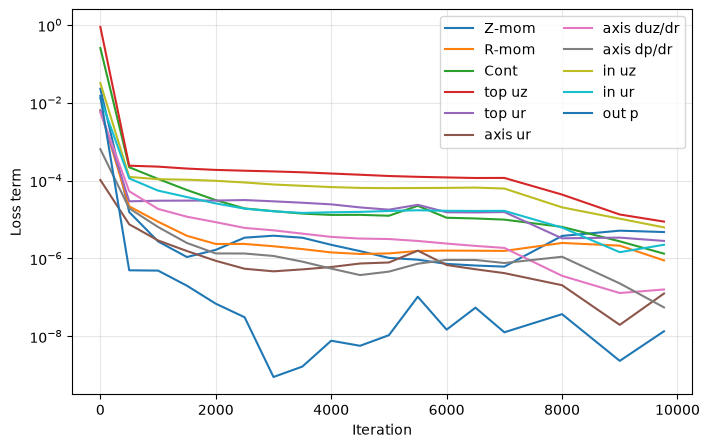

In [8]:
#9) L-BFGS optimizer to finely tune the physics losses
print("Fine-tuning with L-BFGS optimizer...")
model.compile("L-BFGS", loss_weights=weights)
losshistory, train_state = model.train()

labels = ["Z-mom","R-mom","Cont","top uz","top ur","axis ur","axis duz/dr",
          "axis dp/dr","in uz","in ur","out p"]
loss = np.array(losshistory.loss_train)    # (n_logged_steps, 11)
plt.figure(figsize=(8,5))
for i, lab in enumerate(labels):
    plt.semilogy(losshistory.steps, loss[:, i], label=lab)
plt.xlabel("Iteration"); plt.ylabel("Loss term"); plt.legend(ncol=2); plt.grid(alpha=.3)
plt.show(block=False)
plt.pause(0.001)

In [9]:
model.save("models/pinn_model")

'models/pinn_model-9766.pt'

In [10]:
#10) Predict and Visualize Results

# Generate a grid of points to evaluate the trained model
x_vals = np.linspace(0, L_R, 200)
y_vals = np.linspace(0, 1, 200)
X, Y = np.meshgrid(x_vals, y_vals)
points = np.vstack((np.ravel(X), np.ravel(Y))).T

# Make predictions (returns an array of [u, v, p])
predictions = model.predict(points)

# Check predictions before plotting
for i, name in enumerate(["u_z", "u_r", "p"]):
    values = predictions[:, i]
    finite = np.isfinite(values)
    print(f"{name}: {finite.sum()}/{values.size} finite")
    if finite.any():
        print("  range:", values[finite].min(), values[finite].max())

if not np.isfinite(predictions).all():
    raise ValueError(
        "Predictions contain NaN or infinity. Check the training losses."
    )

u_z: 40000/40000 finite
  range: -0.0036220402 0.1671942
u_r: 40000/40000 finite
  range: -0.014885545 0.01503545
p: 40000/40000 finite
  range: -0.0001361724 0.023327906


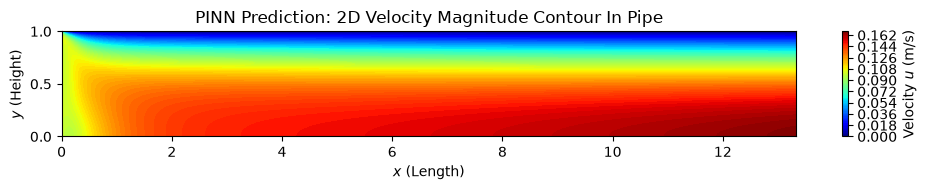

In [11]:
#---Extract velocity components and reshape to grid---
U_velocity = predictions[:, 0].reshape(200, 200)
V_velocity = predictions[:, 1].reshape(200, 200)
pressure = predictions[:, 2].reshape(200, 200)*rho*u0**2
mag_velocity = (U_velocity**2 + V_velocity**2)**0.5

#---Plotting the magnitude contour---
plt.figure(figsize=(10, 2))
contour = plt.contourf(X, Y, mag_velocity, levels=100, cmap='jet')
plt.colorbar(contour, label='Velocity $u$ (m/s)')
plt.title('PINN Prediction: 2D Velocity Magnitude Contour In Pipe')
plt.xlabel('$x$ (Length)')
plt.ylabel('$y$ (Height)')
plt.tight_layout()
plt.show(block=False)
plt.pause(0.001)

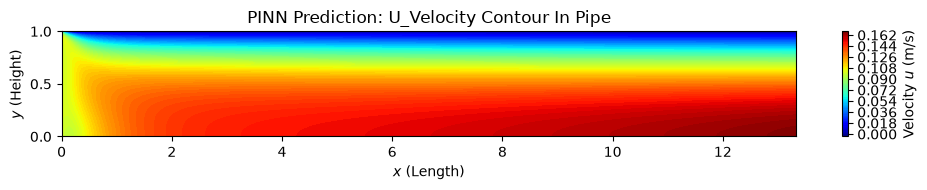

In [12]:

#---Plotting the u_velocity---
plt.figure(figsize=(10, 2))
contour = plt.contourf(X, Y, U_velocity, levels=100, cmap='jet')
plt.colorbar(contour, label='Velocity $u$ (m/s)')
plt.title('PINN Prediction: U_Velocity Contour In Pipe')
plt.xlabel('$x$ (Length)')
plt.ylabel('$y$ (Height)')
plt.tight_layout()
plt.show(block=False)
plt.pause(0.001)

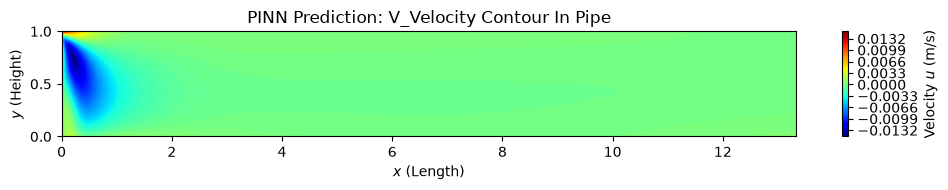

In [13]:

#---Plotting the v_velocity---
plt.figure(figsize=(10, 2))
contour = plt.contourf(X, Y, V_velocity, levels=100, cmap='jet')
plt.colorbar(contour, label='Velocity $u$ (m/s)')
plt.title('PINN Prediction: V_Velocity Contour In Pipe')
plt.xlabel('$x$ (Length)')
plt.ylabel('$y$ (Height)')
plt.tight_layout()
plt.show(block=False)
plt.pause(0.001)

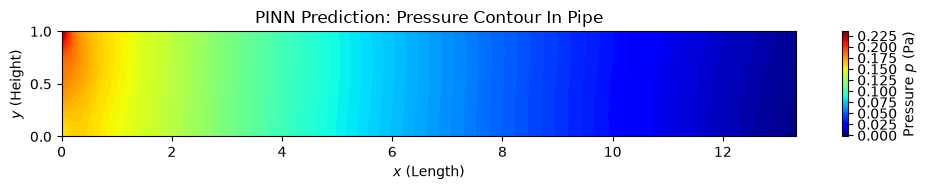

In [14]:

#---Plotting the pressure---
plt.figure(figsize=(10, 2))
contour = plt.contourf(X, Y, pressure, levels=100, cmap='jet')
plt.colorbar(contour, label='Pressure $p$ (Pa)')
plt.title('PINN Prediction: Pressure Contour In Pipe')
plt.xlabel('$x$ (Length)')
plt.ylabel('$y$ (Height)')
plt.tight_layout()
plt.show(block=False)
plt.pause(0.001)

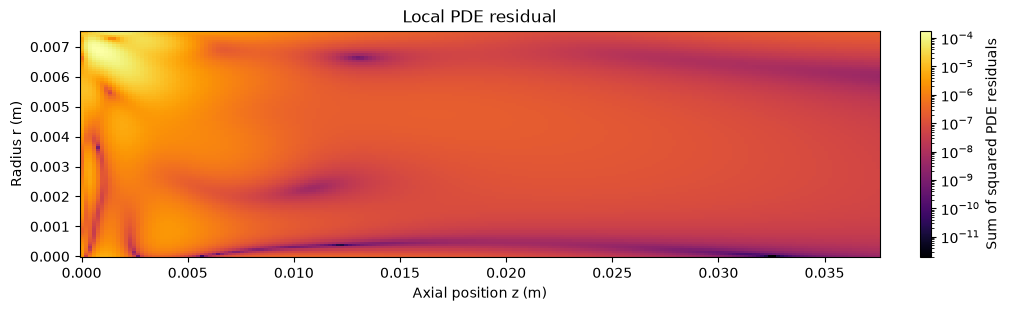

In [15]:

#---Generate total loss heat map---
# Grid: inputs are [z/R, r/R]
z_vals = np.linspace(0, 5, 200)
r_vals = np.linspace(0, 1, 100)
Z, RR = np.meshgrid(z_vals, r_vals)
points = np.column_stack((Z.ravel(), RR.ravel()))

# Evaluate the three PDE residuals using automatic differentiation
residuals = model.predict(points, operator=physLoss)
residuals = np.hstack(residuals)  # Shape: (number of points, 3)

if not np.isfinite(residuals).all():
    raise ValueError(
        "PDE residuals contain NaN or infinity. Check the axis treatment."
    )

# Pointwise sum of squared PDE residuals
local_loss = np.sum(residuals.astype(np.float64)**2, axis=1)
local_loss = local_loss.reshape(Z.shape)

fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)

heatmap = ax.pcolormesh(
    R * Z,
    R * RR,
    np.maximum(local_loss, 1e-20),
    shading="auto",
    cmap="inferno",
    norm=LogNorm(),)

fig.colorbar(heatmap, ax=ax, label="Sum of squared PDE residuals")
ax.set_xlabel("Axial position z (m)")
ax.set_ylabel("Radius r (m)")
ax.set_title("Local PDE residual")
plt.show()
